# Fig: rate-distortion

project = ```iP-VAE```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


def _load_df(files, info_keys=None):

    info_keys = info_keys or [
        'type', 'latent_act', 'str_model',
        'seq_len', 'kl_beta',
    ]
    
    df_ratedist = collections.defaultdict(list)
    for f in tqdm(files):
        if 'softplus' in f or 'sigmoid' in f:
            continue
    
        load = np.load(pjoin(results_dir, f), allow_pickle=True).item()
        info, results = load['info'], load['results']
        
        # all iterative models were batch, epoch = (200, 300)
        # some new fits are (200, 600), skip those
        s = info.get('timestamp')
        if s is not None:
            yy, mm, dd = map(int, s.split(',')[0].split('_'))
            if (mm - 3) * 31 + dd > 25:  
                # print(info)
                continue

        # info
        for k in info_keys:
            df_ratedist[k].append(info.get(k, None))
        df_ratedist['amort'].append('amort' in f)
    
        # results
        try:
            r2 = results['r2'][-1]
            percent_zeros = results['%-zeros'][-1]
        except TypeError:
            r2 = results['r2']
            percent_zeros = results['%-zeros']
        r2_map = results.get('r2_map_final', None)
        if r2_map is None:
            r2_map = r2
    
        distance = np.sqrt(
            (1 - r2) ** 2 +
            (1 - percent_zeros) ** 2
        )
        distance_map = np.sqrt(
            (1 - r2_map) ** 2 +
            (1 - percent_zeros) ** 2
        )
    
        df_ratedist['%-zeros'].append(percent_zeros)
        df_ratedist['r2'].append(r2)
        df_ratedist['r2_map'].append(r2_map)
        df_ratedist['distance'].append(distance)
        df_ratedist['distance_map'].append(distance_map)
    
    df_ratedist = pd.DataFrame(df_ratedist)
    return df_ratedist
# df_ratedist.shape

## Results & Figs dir

In [3]:
pal_models = get_palette_models()

results_dir = pjoin(tmp_dir, 'results_2025-03')
figs_dir = pjoin(fig_base_dir, 'figs_2025-03', 'ratedist')

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figs_dir, exist_ok=True)

len(os.listdir(results_dir)), len(os.listdir(figs_dir))

(624, 12)

## df: rate-distortion

In [4]:
files = [
    f for f in os.listdir(results_dir) if
    any(x in f for x in ('vH16', 'lca'))
]
files = sorted(files, key=alphanum_sort_key)

df_ratedist = _load_df(files)
df_ratedist.shape

100%|█████████████████████████████████████████| 175/175 [00:15<00:00, 10.98it/s]


(139, 11)

### main figs

In [12]:
from figures.final import fig_ratedist_box, fig_ratedist_scatter

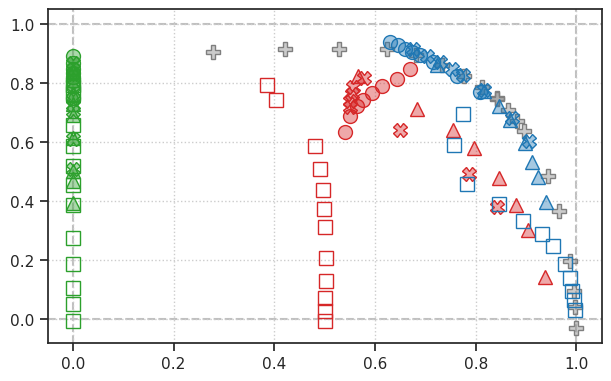

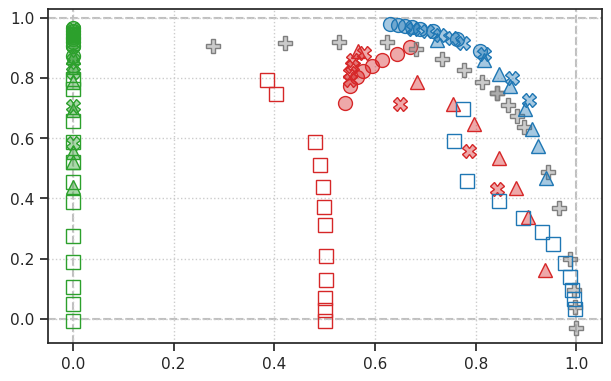

'/home/hadi/Dropbox/git/jb-progress-2025/figs/figs_2025-03/ratedist/ratedist_scatter_map.pdf'

In [13]:
fig = fig_ratedist_scatter(df_ratedist, 'r2')
save_fig('ratedist_scatter.pdf', figs_dir, fig)

fig = fig_ratedist_scatter(df_ratedist, 'r2_map')
save_fig('ratedist_scatter_map.pdf', figs_dir, fig)

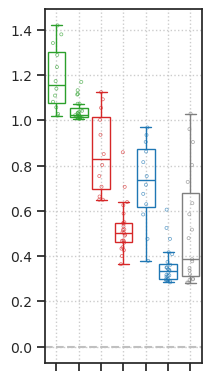

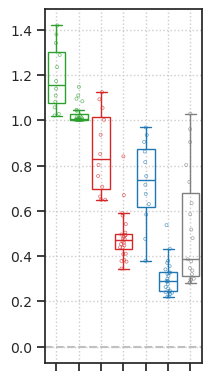

'/home/hadi/Dropbox/git/jb-progress-2025/figs/figs_2025-03/ratedist/ratedist_box_map.pdf'

In [14]:
fig = fig_ratedist_box(df_ratedist, 'distance')
save_fig('ratedist_box.pdf', figs_dir, fig)

fig = fig_ratedist_box(df_ratedist, 'distance_map')
save_fig('ratedist_box_map.pdf', figs_dir, fig)

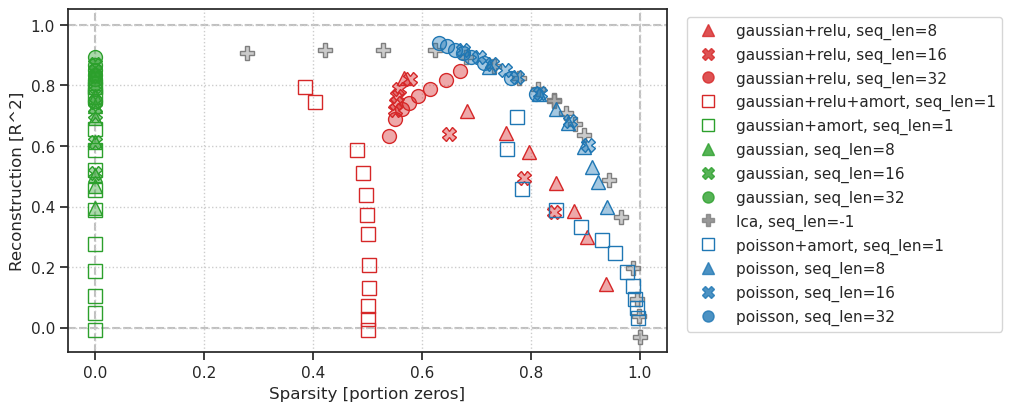

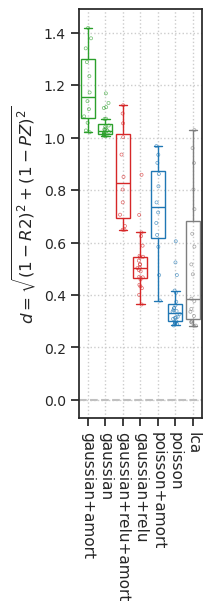

In [15]:
_ = fig_ratedist_scatter(df_ratedist, labels=True, figsize=(10, 4))
_ = fig_ratedist_box(df_ratedist, labels=True, figsize=(2, 6))

In [6]:
df_ratedist.sort_values(by='distance')

,type,latent_act,str_model,seq_len,kl_beta,amort,%-zeros,r2,r2_map,distance,distance_map
89,None,None,lca,-1,0.5,False,0.777586,0.825924,0.825924,0.282437,0.282437
91,None,None,lca,-1,0.6,False,0.813242,0.787064,0.787064,0.283231,0.283231
127,poisson,None,poisson,16,24.0,False,0.775022,0.826882,0.916790,0.283875,0.239873
126,poisson,None,poisson,16,20.0,False,0.752643,0.850000,0.931343,0.289284,0.256709
128,poisson,None,poisson,16,32.0,False,0.815906,0.776233,0.879043,0.289763,0.220275
...,...,...,...,...,...,...,...,...,...,...,...
50,gaussian,softplus,gaussian+softplus+amort,1,2.5,True,0.000000,0.089940,0.089940,1.352113,1.352113
55,gaussian,None,gaussian+amort,1,3.0,True,0.000000,0.049898,0.049898,1.379382,1.379382
56,gaussian,softplus,gaussian+softplus+amort,1,3.0,True,0.000000,0.043657,0.043657,1.383688,1.383688
59,gaussian,softplus,gaussian+softplus+amort,1,4.0,True,0.000000,-0.003781,-0.003781,1.416889,1.416889


In [8]:
df_pois = df_ratedist.loc[df_ratedist['str_model'] == 'poisson']
df_pois = df_pois.sort_values(by='distance')
df_pois

,type,latent_act,str_model,seq_len,kl_beta,amort,%-zeros,r2,r2_map,distance,distance_map
127,poisson,None,poisson,16,24.0,False,0.775022,0.826882,0.916790,0.283875,0.239873
126,poisson,None,poisson,16,20.0,False,0.752643,0.850000,0.931343,0.289284,0.256709
128,poisson,None,poisson,16,32.0,False,0.815906,0.776233,0.879043,0.289763,0.220275
116,poisson,None,poisson,8,8.0,False,0.815630,0.773012,0.857893,0.292431,0.232780
137,poisson,None,poisson,32,96.0,False,0.763749,0.825974,0.928115,0.293428,0.246946
138,poisson,None,poisson,32,128.0,False,0.809028,0.772332,0.889128,0.297158,0.220823
125,poisson,None,poisson,16,16.0,False,0.729082,0.872029,0.943479,0.299622,0.276751
115,poisson,None,poisson,8,4.0,False,0.723470,0.862664,0.924345,0.308755,0.286692
136,poisson,None,poisson,32,64.0,False,0.714716,0.872606,0.954010,0.312436,0.288968
124,poisson,None,poisson,16,12.0,False,0.703835,0.893830,0.953737,0.314620,0.299756


In [9]:
df_lca = df_ratedist.loc[df_ratedist['str_model'] == 'lca']
df_lca = df_lca.sort_values(by='distance')
df_lca

,type,latent_act,str_model,seq_len,kl_beta,amort,%-zeros,r2,r2_map,distance,distance_map
89,None,None,lca,-1,0.50,False,0.777586,0.825924,0.825924,0.282437,0.282437
91,None,None,lca,-1,0.60,False,0.813242,0.787064,0.787064,0.283231,0.283231
102,None,None,lca,-1,0.70,False,0.842296,0.750784,0.750784,0.294922,0.294922
92,None,None,lca,-1,0.70,False,0.841919,0.748479,0.748479,0.297073,0.297073
88,None,None,lca,-1,0.40,False,0.732938,0.863108,0.863108,0.300103,0.300103
93,None,None,lca,-1,0.80,False,0.863878,0.710460,0.710460,0.319941,0.319941
87,None,None,lca,-1,0.30,False,0.680564,0.895463,0.895463,0.336106,0.336106
94,None,None,lca,-1,0.90,False,0.881852,0.673800,0.673800,0.346938,0.346938
95,None,None,lca,-1,1.00,False,0.896629,0.637477,0.637477,0.376973,0.376973
86,None,None,lca,-1,0.20,False,0.622960,0.917777,0.917777,0.385902,0.385902


### Poisson effect of beta fig

In [82]:
df_poisson = df_ratedist.loc[df_ratedist['str_model'] == 'poisson'].copy()
df_poisson['beta_ratio'] = df_poisson['kl_beta'] / df_poisson['seq_len']
df_poisson.shape

(24, 12)

In [83]:
_df = df_poisson.loc[df_poisson['seq_len'] == 16]
xticks = _df['beta_ratio'].values

In [84]:
labels = False

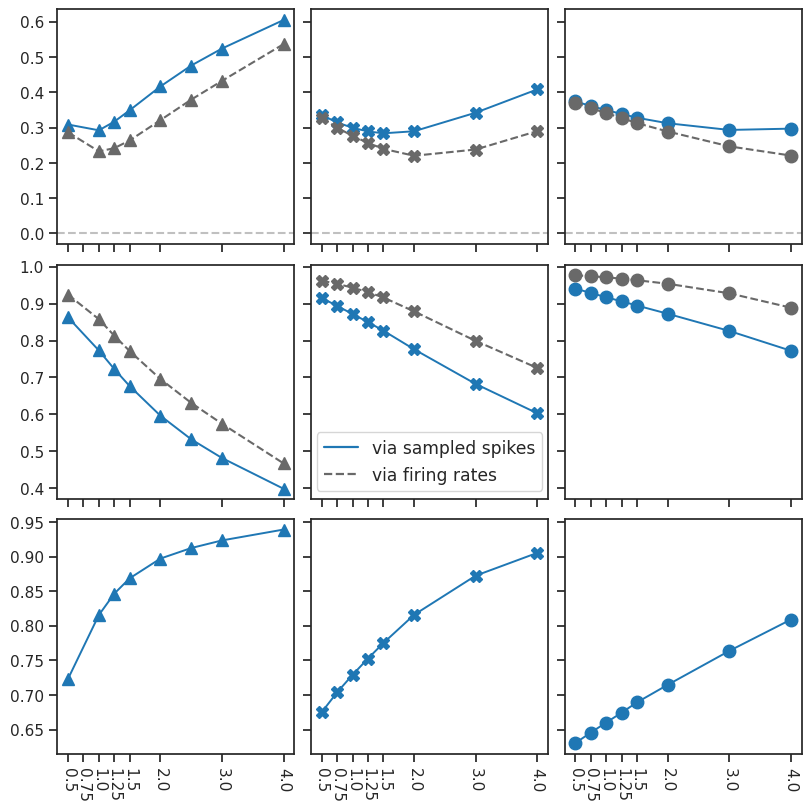

'/home/hadi/Dropbox/git/jb-progress-2025/figs/figs_2025-03/ratedist/ratedist_poisson_beta.pdf'

In [96]:
fig, axes = create_figure(3, 3, (8, 8), sharey='row', sharex='col', layout='tight')

for j, seq_len in enumerate([8, 16, 32]):
    _df = df_poisson.loc[df_poisson['seq_len'] == seq_len]
    for i, key in enumerate(['distance', 'r2', '%-zeros']):
        ax = axes[i, j]
        ax.plot(
            _df['beta_ratio'].values,
            _df[key].values,
            marker=get_marker_style(seq_len)[0],
            color=pal_models['poisson'],
            markersize=9,
            ls='-',
            lw=1.4,
        )
        key_map = f"{key}_map"
        if key_map in _df:
            ax.plot(
                _df['beta_ratio'].values,
                _df[key_map].values,
                marker=get_marker_style(seq_len)[0],
                color='dimgrey',
                markersize=9,
                ls='--',
            )
        if j == 0 and labels:
            ax.set(ylabel=key)
        if i == 2:
            ax.set(
                xticks=xticks,
                xticklabels=xticks,
            )
            ax.tick_params(axis='x', rotation=-90)
for ax in axes[0]:
    ax.axhline(0, color='silver', ls='--', zorder=0)

legend_elements = [
    matplotlib.lines.Line2D(
        [0], [0],
        label='via sampled spikes',
        color=pal_models['poisson'],
        lw=1.6,
        ls='-',
        marker=None),
    matplotlib.lines.Line2D(
        [0], [0],
        label='via firing rates',
        color='dimgrey',
        lw=1.6,
        ls='--',
        marker=None)
]
axes[1, 1].legend(
    handles=legend_elements,
    loc='lower center',
    fontsize=12.4,
)

# add_grid(axes)
save_fig('ratedist_poisson_beta.pdf', figs_dir, fig, display=True)

## Etc (adobe illustrator stuff)

In [21]:
tab10 = sns.color_palette('tab10')
tab10

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [22]:
py_color_to_latex('tab10', 'py')

\definecolor{py_0}{HTML}{1F77B4}
\definecolor{py_1}{HTML}{FF7F0E}
\definecolor{py_2}{HTML}{2CA02C}
\definecolor{py_3}{HTML}{D62728}
\definecolor{py_4}{HTML}{9467BD}
\definecolor{py_5}{HTML}{8C564B}
\definecolor{py_6}{HTML}{E377C2}
\definecolor{py_7}{HTML}{7F7F7F}
\definecolor{py_8}{HTML}{BCBD22}
\definecolor{py_9}{HTML}{17BECF}

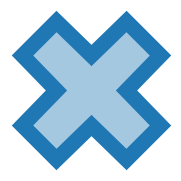

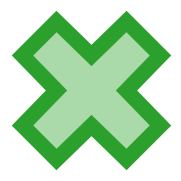

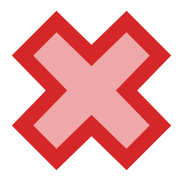

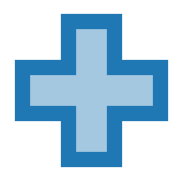

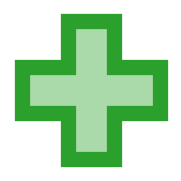

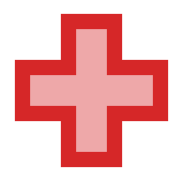

In [8]:
for marker in ['X', 'P']:
    for i in [0, 2, 3]:
        save_marker_as_pdf(marker, figs_dir, f"marker_{marker}_C{i}", face_color=tab10[i], edge_color=tab10[i])

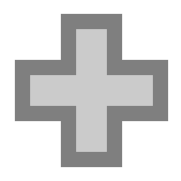

In [9]:
marker = 'P'
i = 7
save_marker_as_pdf(marker, figs_dir, f"marker_{marker}_C{i}", face_color=tab10[i], edge_color=tab10[i])